                                                 ## MAIN PROJECT

## Student Performance and Academic Risk Analytics: Exploratory Analysis of Multi-Source Educational Data Using Python

## Project Overview

This project analyses a multi-source educational dataset to identify patterns and relationships associated with student academic risk. The analysis considers demographic characteristics, academic history, learning engagement, and regional socioeconomic factors.

The project follows an end-to-end data analytics process, including data loading, data cleaning, preprocessing, exploratory data analysis, statistical analysis, visualization, and insight generation.

The analysis will be conducted using Python, primarily using Pandas, NumPy, Matplotlib, Seaborn, and Plotly.



Import Required Libraries
## 1. Importing Required Libraries

The following Python libraries will be used throughout the project. 
Pandas and NumPy will support data manipulation and numerical analysis, 
while Matplotlib, Seaborn, and Plotly will be used to create visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load the Dataset

In [2]:
df=pd.read_csv(r"C:\Users\Jisha\Downloads\Educational Analytics DS for Student Performance and Contextual Analysis.csv")
df.head()

,id_student,code_module,presentation_year,presentation_term,gender,region,highest_education,imd_band,age_band,num_prev_attempts,studied_credits,disability,date_registration,final_weighted_score,total_assessments_submitted,total_clicks,unique_materials_accessed,unemployment_rate,avg_broadband_speed,is_at_risk
0,25997,BBB,2014,B,F,London Region,A Level or Equivalent,20-30%,0-35,2,60,N,-139,74.42,2,13,2,6.8,24.22,1
1,27189,FFF,2014,B,F,South Region,Lower Than A Level,10-20%,35-55,0,120,N,-65,38.00,12,2638,91,5.0,18.12,1
2,28770,EEE,2014,J,M,Scotland,Lower Than A Level,20-30%,0-35,0,30,N,-31,0.00,0,0,0,6.0,14.59,1
3,29144,BBB,2013,B,M,South Region,Lower Than A Level,60-70%,0-35,0,120,N,-24,65.46,9,1914,138,6.0,15.25,1
4,31205,GGG,2014,J,M,East Midlands Region,Lower Than A Level,20-30%,35-55,0,30,Y,-31,0.00,4,381,27,6.5,18.97,1


In [3]:
df.tail()

,id_student,code_module,presentation_year,presentation_term,gender,region,highest_education,imd_band,age_band,num_prev_attempts,studied_credits,disability,date_registration,final_weighted_score,total_assessments_submitted,total_clicks,unique_materials_accessed,unemployment_rate,avg_broadband_speed,is_at_risk
32588,2689210,FFF,2014,B,M,Yorkshire Region,Lower Than A Level,0-10%,0-35,0,60,Y,-61,58.33,11,6560,198,7.3,17.42,0
32589,2692632,FFF,2013,J,M,East Anglian Region,Lower Than A Level,0-10%,0-35,0,120,N,-116,69.00,2,606,54,6.2,16.41,1
32590,2692948,DDD,2014,B,F,Ireland,Lower Than A Level,0-10%,35-55,1,120,N,-165,53.28,5,493,53,6.1,19.78,0
32591,2697885,FFF,2014,B,M,South East Region,Lower Than A Level,30-40%,0-35,1,180,N,-86,77.50,12,1986,160,5.0,20.14,0
32592,2707979,DDD,2013,B,F,East Midlands Region,Lower Than A Level,60-70%,0-35,0,120,N,0,0.00,0,0,0,7.9,15.19,1


## Initial Dataset Overview
Before performing any cleaning or analysis, the dataset will be examined to understand its size, structure, variable types,
and initial characteristics. This step helps identify potential data quality issues that need to be addressed during preprocessing.

In [4]:
print("Number of rows:",df.shape[0])
print("Number of Columns:", df.shape[1])

Number of rows: 32593
Number of Columns: 20


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_student                   32593 non-null  int64  
 1   code_module                  32593 non-null  str    
 2   presentation_year            32593 non-null  int64  
 3   presentation_term            32593 non-null  str    
 4   gender                       32593 non-null  str    
 5   region                       32593 non-null  str    
 6   highest_education            32593 non-null  str    
 7   imd_band                     32593 non-null  str    
 8   age_band                     32593 non-null  str    
 9   num_prev_attempts            32593 non-null  int64  
 10  studied_credits              32593 non-null  int64  
 11  disability                   32593 non-null  str    
 12  date_registration            32593 non-null  int64  
 13  final_weighted_score       

In [6]:
df.dtypes

id_student                       int64
code_module                        str
presentation_year                int64
presentation_term                  str
gender                             str
region                             str
highest_education                  str
imd_band                           str
age_band                           str
num_prev_attempts                int64
studied_credits                  int64
disability                         str
date_registration                int64
final_weighted_score           float64
total_assessments_submitted      int64
total_clicks                     int64
unique_materials_accessed        int64
unemployment_rate              float64
avg_broadband_speed            float64
is_at_risk                       int64
dtype: object

In [7]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_student,32593.0,NaN,NaN,NaN,706687.669131,549167.313855,3733.0,508573.0,590310.0,644453.0,2716795.0
code_module,32593,7,BBB,7909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
presentation_year,32593.0,NaN,NaN,NaN,2013.584911,0.492745,2013.0,2013.0,2014.0,2014.0,2014.0
presentation_term,32593,2,J,20105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,32593,2,M,17875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,32593,13,Scotland,3446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
highest_education,32593,5,A Level or Equivalent,14045,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imd_band,32593,10,10-20%,4247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_band,32593,3,0-35,22944,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_prev_attempts,32593.0,NaN,NaN,NaN,0.163225,0.479758,0.0,0.0,0.0,0.0,6.0


In [8]:
df.describe()

,id_student,presentation_year,num_prev_attempts,studied_credits,date_registration,final_weighted_score,total_assessments_submitted,total_clicks,unique_materials_accessed,unemployment_rate,avg_broadband_speed,is_at_risk
count,3.259300e+04,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000,32593.000000
mean,7.066877e+05,2013.584911,0.163225,79.758691,-69.315467,50.142434,5.335870,1215.141257,60.150830,6.813985,17.310658,0.527966
std,5.491673e+05,0.492745,0.479758,41.071900,49.293930,34.343584,4.326009,1692.604449,55.898555,1.229529,2.938699,0.499225
min,3.733000e+03,2013.000000,0.000000,30.000000,-322.000000,0.000000,0.000000,0.000000,0.000000,5.000000,11.710000,0.000000
25%,5.085730e+05,2013.000000,0.000000,60.000000,-100.000000,0.000000,1.000000,142.000000,19.000000,6.000000,15.100000,0.000000
50%,5.903100e+05,2014.000000,0.000000,60.000000,-57.000000,63.000000,5.000000,602.000000,46.000000,6.700000,16.830000,1.000000
75%,6.444530e+05,2014.000000,0.000000,120.000000,-29.000000,78.160000,9.000000,1585.000000,86.000000,7.700000,19.620000,1.000000
max,2.716795e+06,2014.000000,6.000000,655.000000,167.000000,100.000000,14.000000,24139.000000,413.000000,9.700000,24.220000,1.000000


In [9]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns.tolist()

['id_student',
 'code_module',
 'presentation_year',
 'presentation_term',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_prev_attempts',
 'studied_credits',
 'disability',
 'date_registration',
 'final_weighted_score',
 'total_assessments_submitted',
 'total_clicks',
 'unique_materials_accessed',
 'unemployment_rate',
 'avg_broadband_speed',
 'is_at_risk']

##  Missing Value Assessment

The dataset will be examined for missing values to determine whether any variables contain incomplete observations. 
The number and percentage of missing values will be calculated to support decisions regarding appropriate treatment.

In [10]:
# Calculate the number of missing values
missing_count=df.isnull().sum()

# Calculate the percentage of missing value
missing_percentage= df.isnull().sum()/len(df)*100

# Create a summary table
missing_summary=pd.DataFrame({'Missing Values':missing_count,
                              'Missing Percentage':missing_percentage})
missing_summary.sort_values(
    by='Missing Values',
    ascending=False
)
# Display the summary
missing_summary
        

,Missing Values,Missing Percentage
id_student,0,0.0
code_module,0,0.0
presentation_year,0,0.0
presentation_term,0,0.0
gender,0,0.0
region,0,0.0
highest_education,0,0.0
imd_band,0,0.0
age_band,0,0.0
num_prev_attempts,0,0.0


## Duplicate Record Assessment

Duplicate records are checked because repeated observations can distort statistical summaries and subsequent analysis. 
Any duplicates identified will be evaluated before deciding whether they should be removed.

In [11]:
duplicate_count=df.duplicated().sum()
print("number of duplicate records:",duplicate_count)

number of duplicate records: 0


### Examination of Categorical Variables

The unique values and frequency distributions of categorical variables are examined to identify inconsistent labels, unexpected categories, or formatting issues that may require standardisation.



In [12]:
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print("\nColumn:", column)
    print(df[column].value_counts(dropna=False).head(20))


Column: code_module
code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64

Column: presentation_term
presentation_term
J    20105
B    12488
Name: count, dtype: int64

Column: gender
gender
M    17875
F    14718
Name: count, dtype: int64

Column: region
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64

Column: highest_education
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

Column: im

C:\Users\Jisha\AppData\Local\Temp\ipykernel_8872\2761403968.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


### Validation of the `date_registration` Variable

The `date_registration` variable contains both negative and positive values. These values do not necessarily represent data errors because the variable records registration timing relative to the reference date of the course presentation. Negative values indicate registration before the reference date, while positive values indicate registration after the reference date. Therefore, the values were retained rather than removed or converted to absolute values. 
The variable will be used in its original form for subsequent analysis.

## . Creating Derived Columns

Derived variables are created from existing variables to support more meaningful analysis. 
In this project, an engagement level variable will be derived from students' total Virtual Learning Environment (VLE) clicks. 
This categorises students according to their level of online learning engagement and will support subsequent analysis of the relationship 
between engagement and academic performance.

The derived variable is created after reviewing the distribution of `total_clicks`,
while the original variable is retained to preserve the information contained in the raw dataset.

In [13]:
df['engagement_level'] = pd.qcut(
    df['total_clicks'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High'],
    duplicates='drop'
)
# Display the first few records
df[['total_clicks', 'engagement_level']].head(10)

,total_clicks,engagement_level
0,13,Low
1,2638,Very High
2,0,Low
3,1914,Very High
4,381,Medium
5,0,Low
6,213,Medium
7,0,Low
8,0,Low
9,411,Medium


## Filtering the Dataset

Filtering is used to examine specific groups of observations without permanently removing records from the original dataset. In this project, a subset of students classified as having very high engagement will be examined to understand their characteristics and academic outcomes.

The original dataset will be retained, ensuring that filtering does not result in the loss of valid observations.

In [14]:
# Filter students classified as having very high engagement

high_engagement_students = df[
    df['engagement_level'] == 'Very High'
]

# Display the first few records
high_engagement_students.head()

,id_student,code_module,presentation_year,presentation_term,gender,region,highest_education,imd_band,age_band,num_prev_attempts,...,disability,date_registration,final_weighted_score,total_assessments_submitted,total_clicks,unique_materials_accessed,unemployment_rate,avg_broadband_speed,is_at_risk,engagement_level
1,27189,FFF,2014,B,F,South Region,Lower Than A Level,10-20%,35-55,0,...,N,-65,38.00,12,2638,91,5.0,18.12,1,Very High
3,29144,BBB,2013,B,M,South Region,Lower Than A Level,60-70%,0-35,0,...,N,-24,65.46,9,1914,138,6.0,15.25,1,Very High
11,43273,FFF,2013,B,M,East Midlands Region,HE Qualification,60-70%,35-55,0,...,N,-108,70.75,12,1862,112,7.9,15.19,0,Very High
13,46605,CCC,2014,B,M,East Anglian Region,HE Qualification,60-70%,35-55,0,...,N,-54,95.61,9,3427,107,5.6,20.01,0,Very High
15,48040,BBB,2013,J,F,East Midlands Region,A Level or Equivalent,20-30%,35-55,0,...,N,-92,63.60,11,1829,127,7.9,15.19,0,Very High


##  Aggregating Data by Course Module

Aggregation is used to summarise student-level information at a higher level. In this analysis, student records are grouped by course module to compare the average academic score, average VLE engagement, and number of observations across modules.

This provides an initial view of differences in academic performance and engagement between course modules.

In [15]:
module_summary = df.groupby('code_module').agg(
    average_score=('final_weighted_score', 'mean'),
    average_clicks=('total_clicks', 'mean'),
    average_assessments=('total_assessments_submitted', 'mean'),
    student_count=('id_student', 'count')
)

module_summary

,average_score,average_clicks,average_assessments,student_count
code_module,,,,
AAA,63.977166,1666.647059,4.209893,748
BBB,51.796763,661.799975,5.440890,7909
CCC,49.618935,1055.965043,4.271538,4434
DDD,50.533418,881.710619,4.920918,6272
EEE,62.153125,1357.950579,2.690184,2934
FFF,58.936306,2266.673795,7.061969,7762
GGG,0.000000,526.394633,6.005919,2534


Data Cleaning Summary

The dataset was initially examined to understand its structure, data types, categorical variables, numerical variables, and overall data quality. Missing-value analysis was conducted by calculating both the number and percentage of missing observations for each variable. Categorical variables were further assessed using frequency distributions to identify the number of observations within each category and to check for potential missing or inconsistent values.

The numerical variables were reviewed using descriptive statistics to identify their minimum, maximum, mean, median, and distributional characteristics. Particular attention was given to variables such as date_registration, where negative values were identified. These values were retained because they represent registration timing relative to the course presentation reference date rather than invalid numerical values.

The dataset was also assessed for duplicate records and inappropriate data types. Where variables were already stored in suitable numerical or categorical formats, no unnecessary conversion was performed. A derived engagement_level variable was created from total_clicks to categorise students into Low, Medium, High, and Very High engagement groups. Filtering and aggregation were then used to create meaningful subsets and summaries for subsequent exploratory analysis.

Overall, the preprocessing stage focused on preserving valid information, identifying potential data-quality issues, and transforming the raw dataset into a structured format suitable for exploratory data analysis. The original variables were retained wherever possible to maintain data integrity and traceability.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is conducted to identify patterns, distributions, relationships, and potential anomalies within the cleaned educational dataset. The analysis is structured into univariate, bivariate, and multivariate analysis in accordance with the project objectives.

Univariate analysis examines individual variables, bivariate analysis investigates relationships between two variables, and multivariate analysis considers relationships among multiple variables simultaneously. A combination of Matplotlib, Seaborn, and Plotly will be used to produce clear and meaningful visualisations.

The analysis focuses particularly on student demographics, learning engagement, academic outcomes, previous academic experience, and contextual socioeconomic indicators.

In [16]:
df.columns.tolist()

['id_student',
 'code_module',
 'presentation_year',
 'presentation_term',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_prev_attempts',
 'studied_credits',
 'disability',
 'date_registration',
 'final_weighted_score',
 'total_assessments_submitted',
 'total_clicks',
 'unique_materials_accessed',
 'unemployment_rate',
 'avg_broadband_speed',
 'is_at_risk',
 'engagement_level']

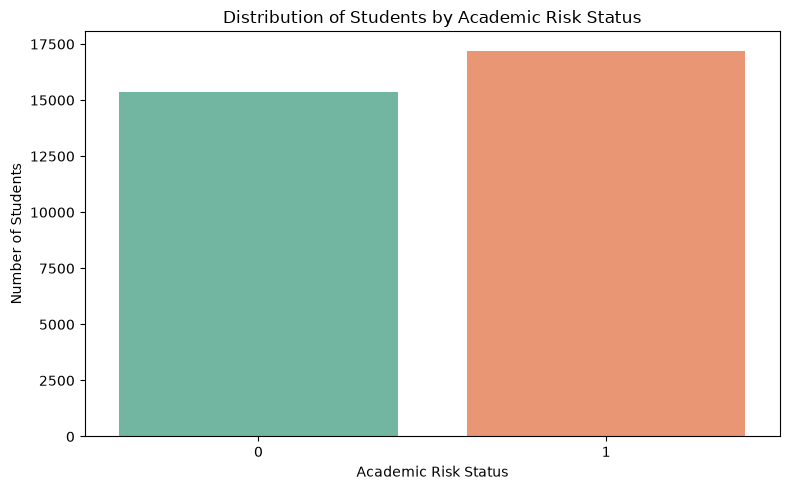

In [17]:
# A. UNIVARIATE ANALYSIS
# Visualisation 1 — Academic Risk Distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='is_at_risk',
    hue='is_at_risk',
    palette='Set2',
    legend=False
)

plt.title('Distribution of Students by Academic Risk Status')
plt.xlabel('Academic Risk Status')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

Summary: The chart shows that the dataset contains a relatively balanced distribution between students classified as academically at risk and those not classified as at risk. However, the number of students in the at-risk category (1) is slightly higher than the non-risk category (0). This provides a suitable basis for comparing academic risk patterns across demographic, behavioural, and contextual variables.

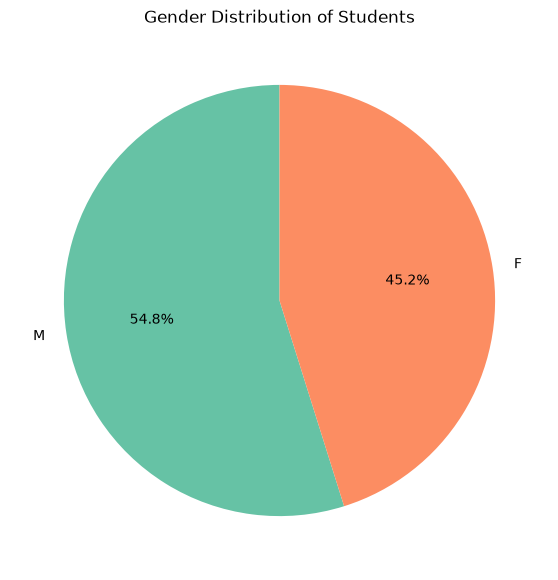

In [18]:
# Visualisation 2 — Gender Distribution

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62']
)

plt.title('Gender Distribution of Students')
plt.show()

Summary:
The gender distribution shows that male students represent 54.8% of the dataset, while female students account for 45.2%. Therefore, the dataset contains a moderately higher proportion of male students, although both groups are sufficiently represented for further comparative analysis.

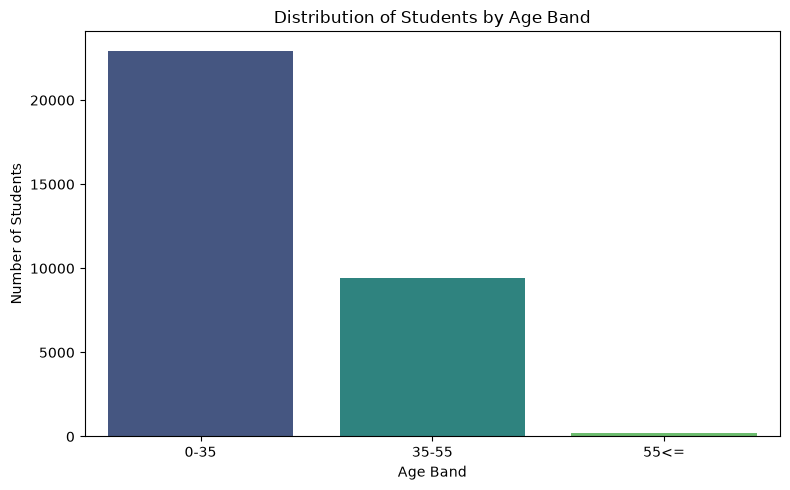

In [19]:
# Visualisation 3 — Age Band Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='age_band',
    hue='age_band',
    palette='viridis',
    legend=False
)

plt.title('Distribution of Students by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

Summary:
The age distribution is strongly concentrated in the 0–35 age group, which represents the majority of students. The 35–55 age group forms the second-largest category, while students aged 55 and above represent only a very small proportion of the dataset. This indicates that the dataset is predominantly composed of younger learners.

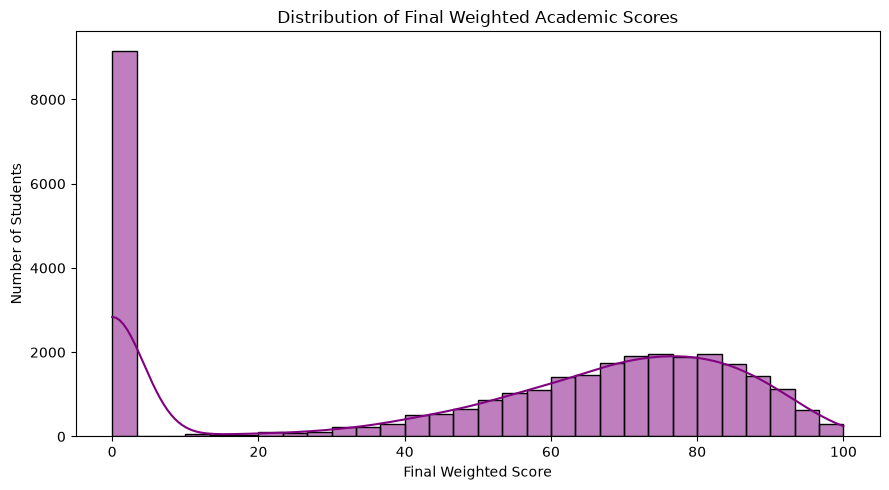

In [20]:
# Visualisation 4 — Distribution of Final Academic Scores
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='final_weighted_score',
    bins=30,
    kde=True,
    color='purple'
)

plt.title('Distribution of Final Weighted Academic Scores')
plt.xlabel('Final Weighted Score')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

Summary:
The distribution shows a strong concentration of scores around zero, together with a broader distribution of higher scores among students who achieved better academic outcomes. This suggests substantial variation in academic performance, with a notable group of students recording zero or very low scores. The distribution therefore indicates the presence of both low-performing students and students achieving relatively high final scores.

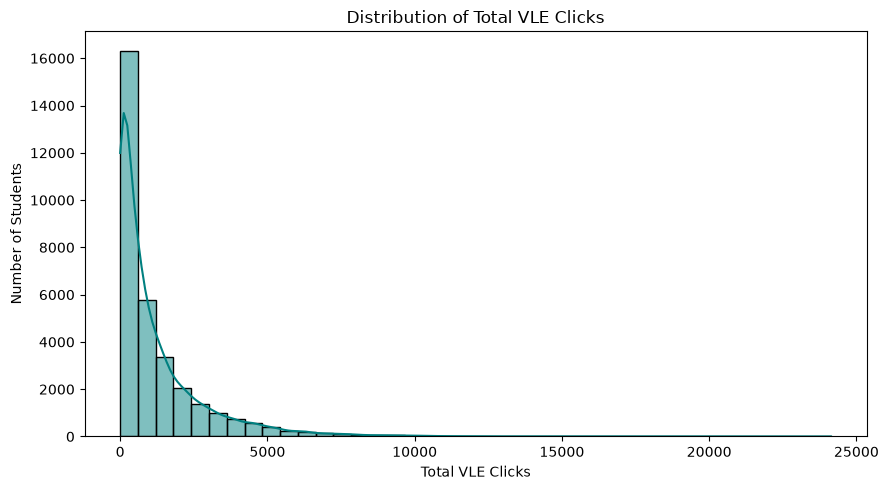

In [21]:
# Visualisation 5 — Distribution of VLE Engagement
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='total_clicks',
    bins=40,
    kde=True,
    color='teal'
)

plt.title('Distribution of Total VLE Clicks')
plt.xlabel('Total VLE Clicks')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

Summary:
The distribution of total VLE clicks is strongly right-skewed. Most students record relatively low to moderate levels of online interaction, while a small number of students record exceptionally high numbers of clicks. This indicates considerable variation in students' engagement with the Virtual Learning Environment (VLE).

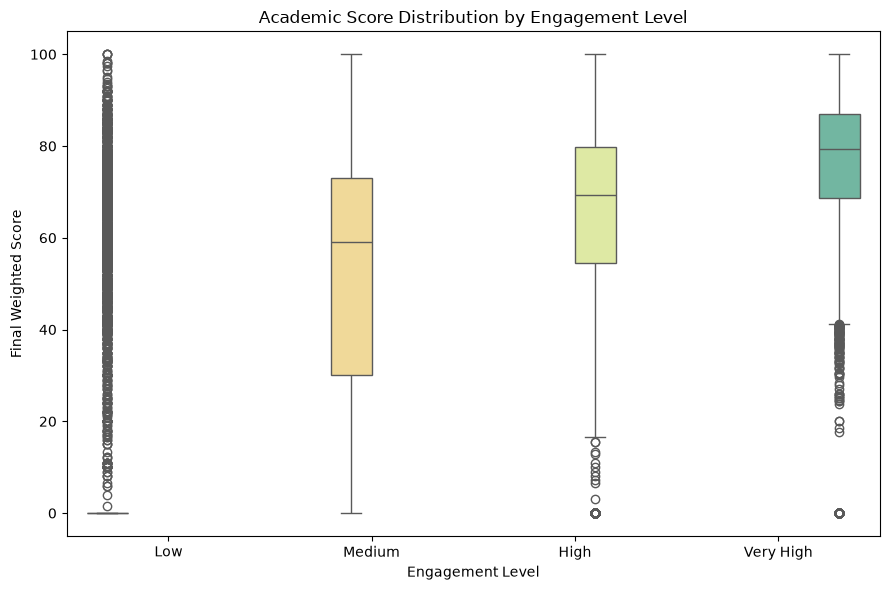

In [22]:
# B. BIVARIATE ANALYSIS
# Visualisation 6 — Engagement Level vs Academic Score
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='engagement_level',
    y='final_weighted_score',
    hue='engagement_level',
    palette='Spectral',
    legend=False
)

plt.title('Academic Score Distribution by Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Final Weighted Score')
plt.tight_layout()
plt.show()

Summary:
The box plot indicates a clear positive association between engagement level and academic performance. Students in higher engagement categories generally have higher median final scores, while students with low engagement show a much greater concentration of zero or very low scores. Overall, the pattern suggests that higher levels of VLE engagement are associated with stronger academic performance in this dataset.

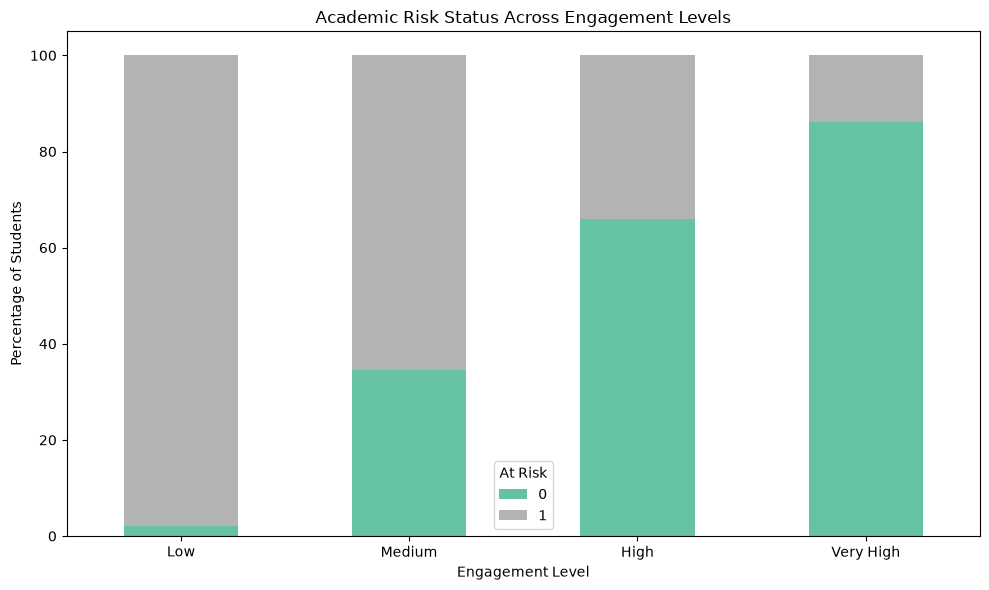

In [23]:
# Visualisation 7 — Engagement Level vs Academic Risk
risk_engagement = pd.crosstab(
    df['engagement_level'],
    df['is_at_risk'],
    normalize='index'
) * 100

risk_engagement.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='Set2'
)

plt.title('Academic Risk Status Across Engagement Levels')
plt.xlabel('Engagement Level')
plt.ylabel('Percentage of Students')
plt.legend(title='At Risk')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The proportion of academically at-risk students varies considerably across engagement levels. The Low engagement category contains a substantially higher proportion of at-risk students, while the proportion of at-risk students decreases as engagement increases. This indicates a strong association between students' VLE engagement levels and their academic risk status.

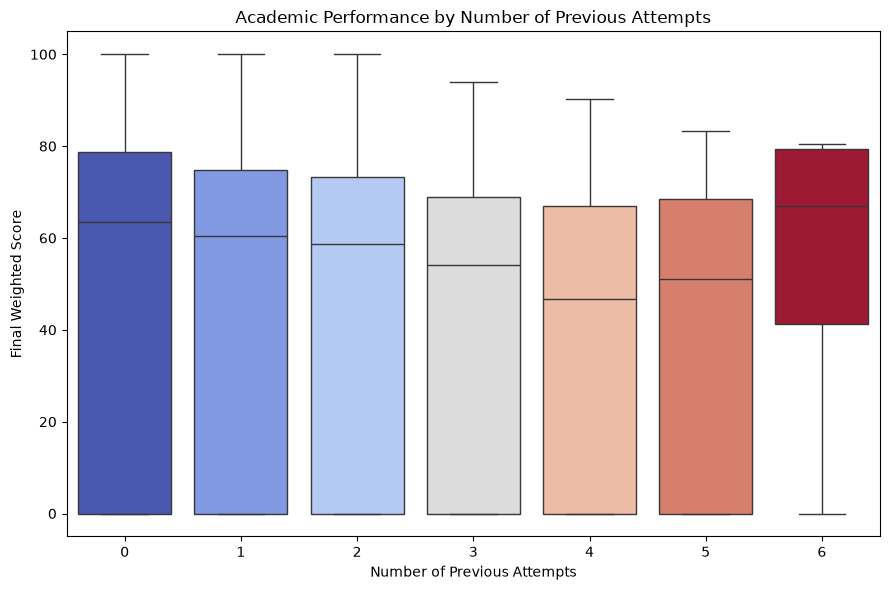

In [24]:
# Visualisation 8 — Previous Attempts vs Academic Score
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='num_prev_attempts',
    y='final_weighted_score',
    hue='num_prev_attempts',
    palette='coolwarm',
    legend=False
)

plt.title('Academic Performance by Number of Previous Attempts')
plt.xlabel('Number of Previous Attempts')
plt.ylabel('Final Weighted Score')
plt.tight_layout()
plt.show()

Summary:
The analysis shows differences in final academic scores across students with different numbers of previous attempts. Students with no previous attempts generally have higher median scores than several groups with multiple previous attempts. The groups with five and six previous attempts show greater variation, which may partly reflect the relatively small number of students in these categories. Overall, previous attempts appear to be associated with differences in academic performance.

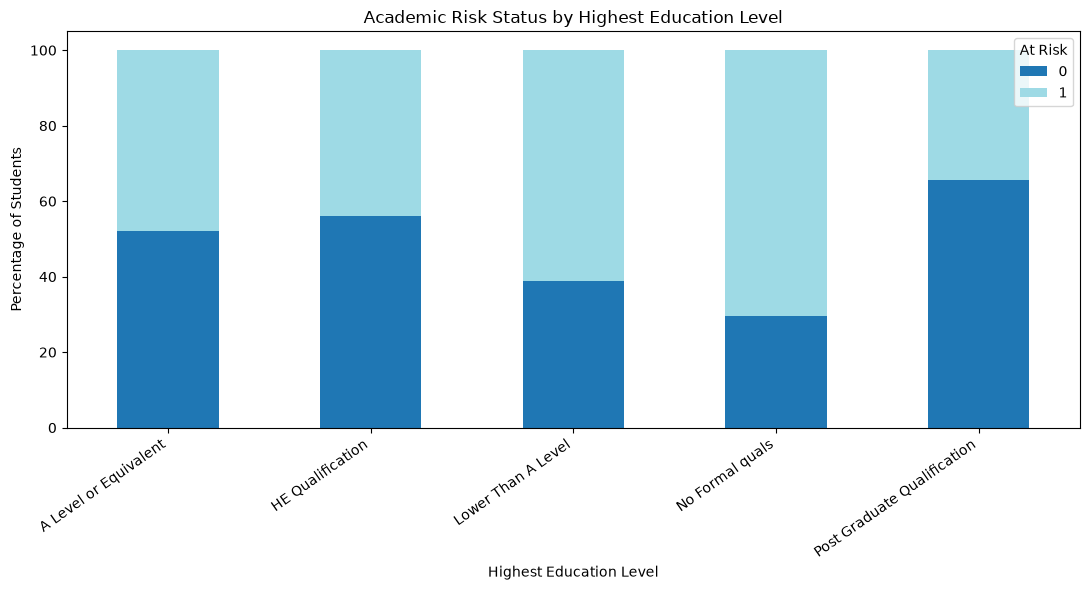

In [25]:
# Visualisation 9 — Education Level vs Academic Risk
education_risk = pd.crosstab(
    df['highest_education'],
    df['is_at_risk'],
    normalize='index'
) * 100

education_risk.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6),
    colormap='tab20'
)

plt.title('Academic Risk Status by Highest Education Level')
plt.xlabel('Highest Education Level')
plt.ylabel('Percentage of Students')
plt.legend(title='At Risk')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

Summary:
Academic risk varies across different levels of prior educational attainment. Students with higher educational qualifications generally show a greater proportion of students classified as not at risk, while students with lower or no formal qualifications show comparatively higher levels of academic risk. This suggests an association between students' prior educational background and their academic risk status.

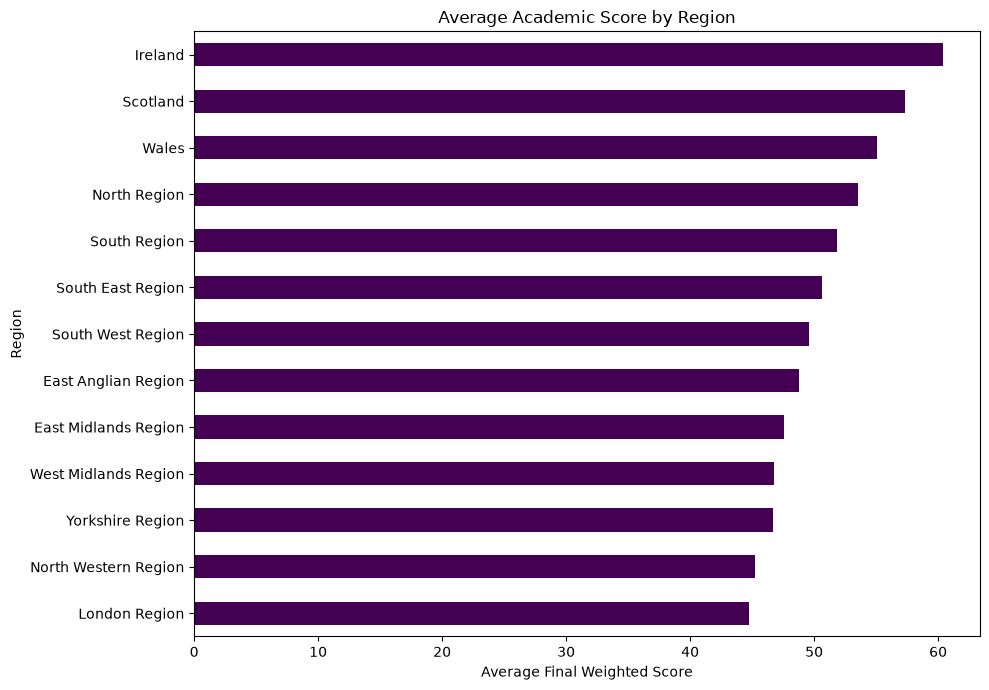

In [26]:
# Visualisation 10 — Region vs Academic Score
region_score = (
    df.groupby('region')['final_weighted_score']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 7))

region_score.plot(
    kind='barh',
    colormap='viridis'
)

plt.title('Average Academic Score by Region')
plt.xlabel('Average Final Weighted Score')
plt.ylabel('Region')
plt.tight_layout()
plt.show()


Summary:
The horizontal bar chart indicates notable regional differences in average final weighted scores. Ireland records the highest average score at approximately 60.5, followed by Scotland (57.3) and Wales (55.1). In contrast, the London Region (44.8) and North Western Region (45.2) record comparatively lower average scores. These differences indicate regional variation in student academic performance within the dataset.

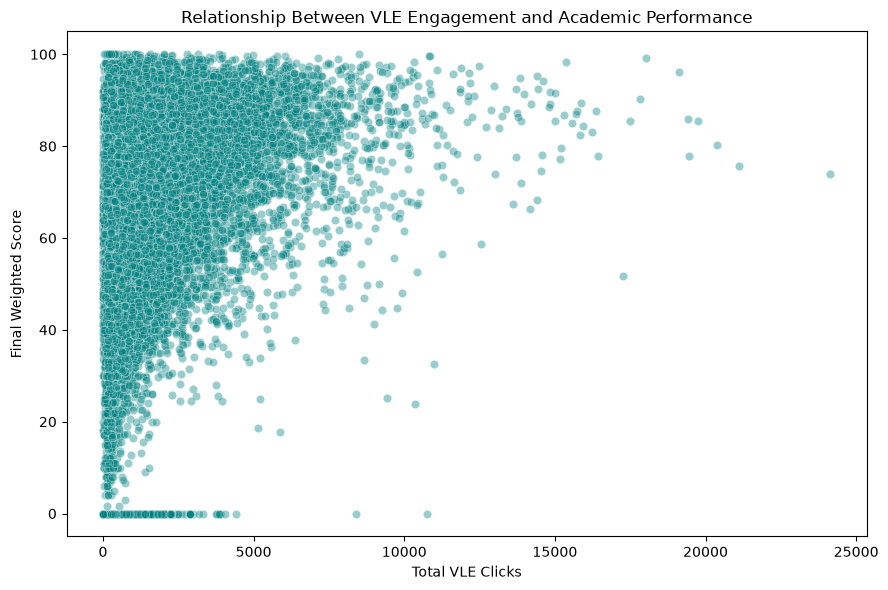

In [27]:
# Visualisation 11 — VLE Clicks vs Academic Score
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='total_clicks',
    y='final_weighted_score',
    alpha=0.4,
    color='teal'
)

plt.title('Relationship Between VLE Engagement and Academic Performance')
plt.xlabel('Total VLE Clicks')
plt.ylabel('Final Weighted Score')
plt.tight_layout()
plt.show()

Summary:
The scatter plot indicates a positive and non-linear association between total VLE clicks and final weighted scores. Students with relatively low levels of VLE activity show considerable variation in academic scores, including a substantial concentration of zero scores. At higher levels of VLE activity, scores are generally concentrated at higher levels. Overall, the pattern suggests that greater VLE interaction is associated with stronger academic performance.

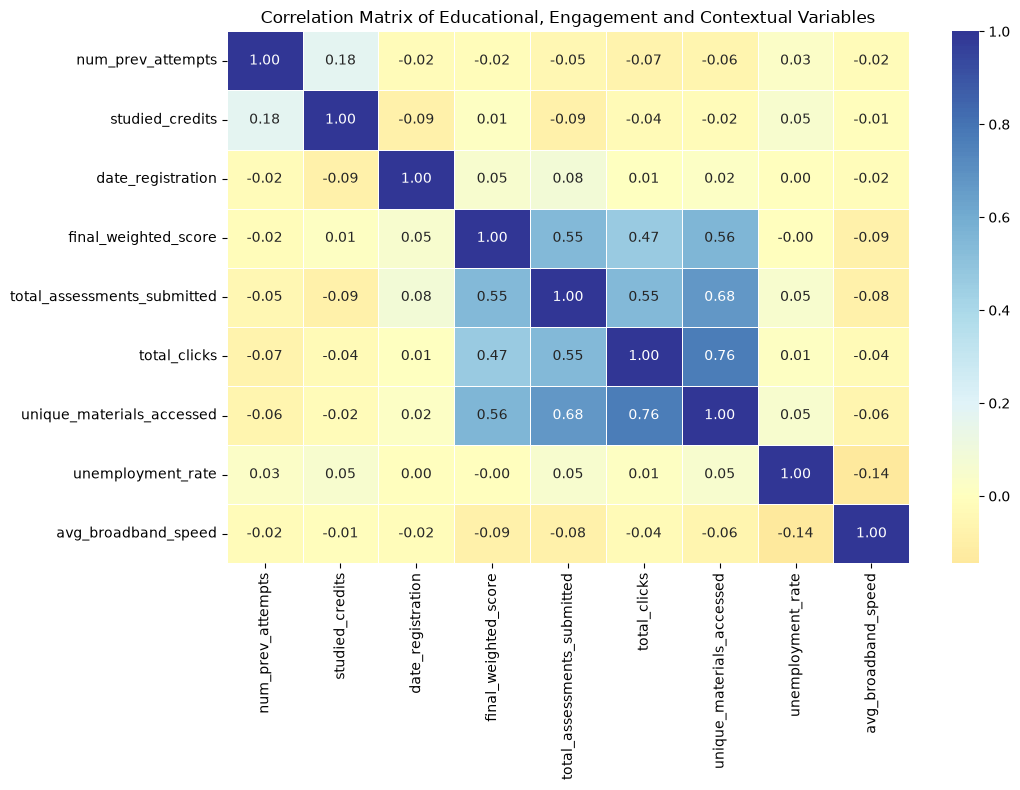

In [28]:
# C. MULTIVARIATE ANALYSIS
# Visualisation 12 — Correlation Heatmap
numeric_columns = [
    'num_prev_attempts',
    'studied_credits',
    'date_registration',
    'final_weighted_score',
    'total_assessments_submitted',
    'total_clicks',
    'unique_materials_accessed',
    'unemployment_rate',
    'avg_broadband_speed'
]

correlation_matrix = df[numeric_columns].corr()
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix of Educational, Engagement and Contextual Variables')
plt.tight_layout()
plt.show()

Summary:
The correlation heatmap shows strong positive relationships among several learning engagement measures. Total clicks and unique materials accessed have a strong positive correlation (r = 0.76), while total assessments submitted and unique materials accessed also show a substantial positive correlation (r = 0.68). Final weighted score has moderate positive correlations with materials accessed (r = 0.56), assessments submitted (r = 0.55), and total clicks (r = 0.47). In contrast, unemployment rate and average broadband speed show relatively weak linear relationships with the other variables, with correlation coefficients generally close to zero.


Students who interact more with the VLE also tend to access more learning materials and submit more assessments. Academic scores also tend to be higher among students showing greater engagement.

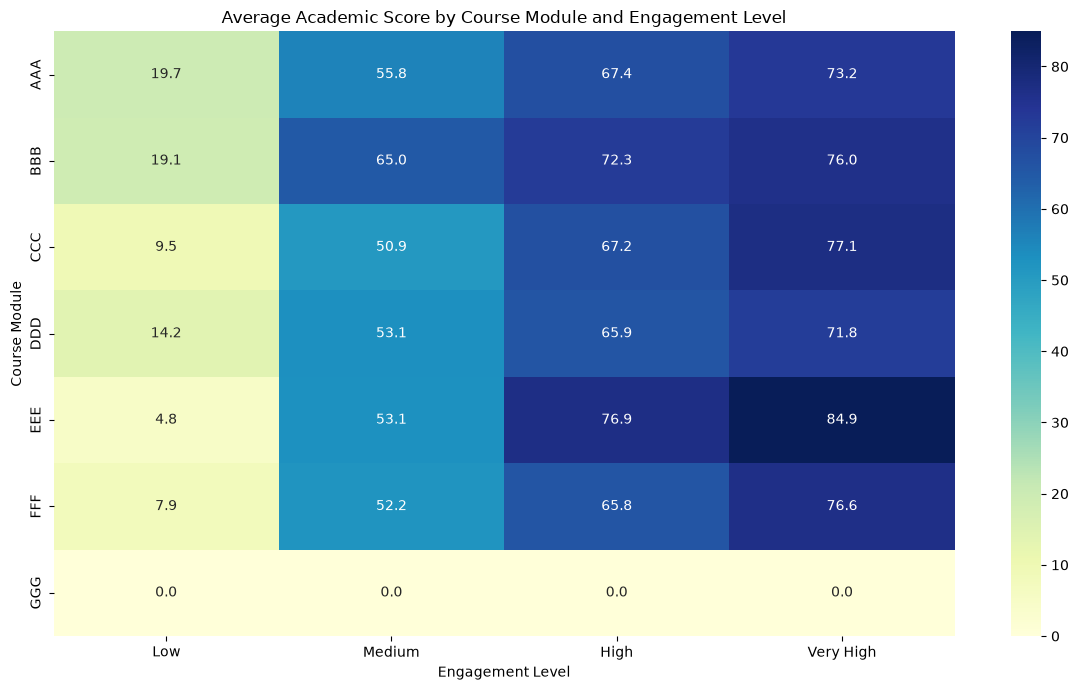

In [29]:
# Visualisation 13 — Module × Engagement × Academic Score
module_engagement = df.pivot_table(
    values='final_weighted_score',
    index='code_module',
    columns='engagement_level',
    aggfunc='mean',
    observed=True
)

module_engagement

plt.figure(figsize=(12, 7))

sns.heatmap(
    module_engagement,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Average Academic Score by Course Module and Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Course Module')
plt.tight_layout()
plt.show()

Summary:
The pivot heatmap demonstrates a consistent association between engagement level and academic performance across most course modules. For example, the average score for module EEE increases from approximately 4.8 at Low engagement to 84.9 at Very High engagement. Similar increases can be observed across several other modules, with average scores generally rising substantially as engagement increases. Module GGG shows zero values across the engagement categories, which should be investigated further to determine whether this reflects missing, non-graded, or unavailable outcome data.

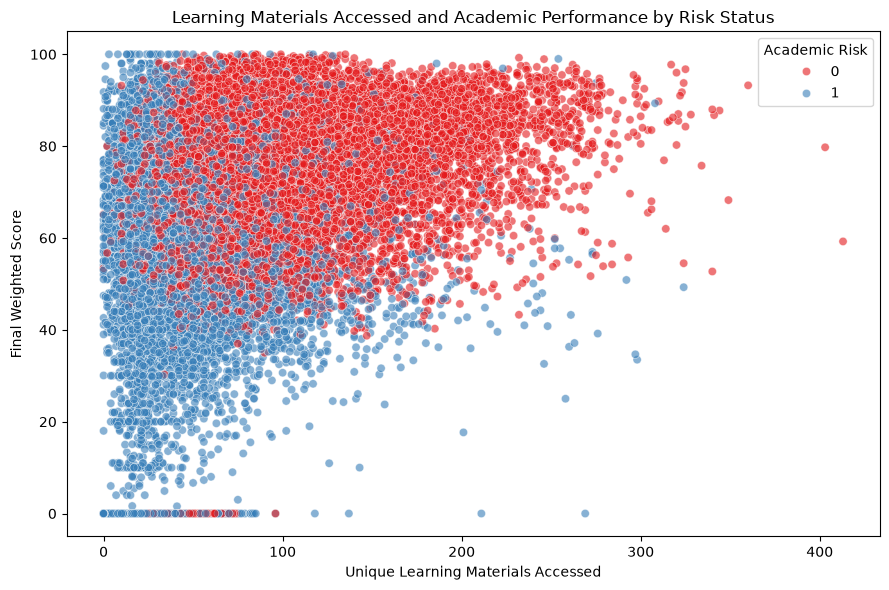

In [30]:
# Visualisation 14 — Learning Materials vs Academic Score
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='unique_materials_accessed',
    y='final_weighted_score',
    hue='is_at_risk',
    palette='Set1',
    alpha=0.6
)

plt.title('Learning Materials Accessed and Academic Performance by Risk Status')
plt.xlabel('Unique Learning Materials Accessed')
plt.ylabel('Final Weighted Score')
plt.legend(title='Academic Risk')
plt.tight_layout()
plt.show()

Summary:
The scatter plot shows a noticeable difference in the distribution of students according to academic risk status. Students classified as not at risk (0) are more frequently observed at higher final weighted scores and greater numbers of unique learning materials accessed. In contrast, students classified as at risk (1) are more concentrated in areas representing lower material access and lower academic scores. Overall, the pattern indicates a strong association between learning-material engagement, academic performance, and academic risk.

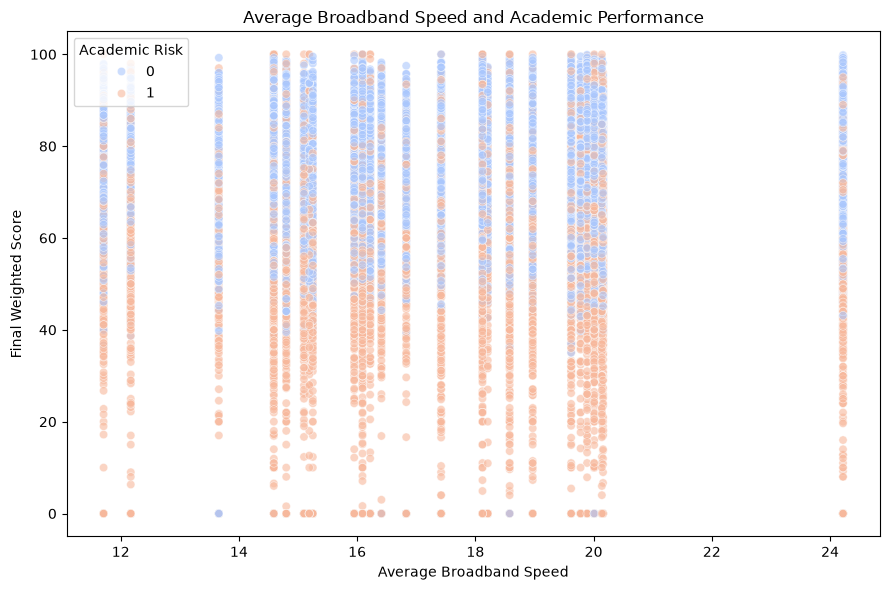

In [31]:
# 15th visualisation
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='avg_broadband_speed',
    y='final_weighted_score',
    hue='is_at_risk',
    palette='coolwarm',
    alpha=0.6
)

plt.title('Average Broadband Speed and Academic Performance')
plt.xlabel('Average Broadband Speed')
plt.ylabel('Final Weighted Score')
plt.legend(title='Academic Risk')
plt.tight_layout()
plt.show()

Summary:
The scatter plot shows that students with different academic scores and risk statuses are distributed across the available broadband-speed range of approximately 11.8 to 24.2 Mbps. Both high-performing and at-risk students appear across most broadband-speed levels. This suggests that average regional broadband speed has a relatively weak visible association with individual academic performance within this dataset.

# <!-- Overall Summary of the 15 Visualisations -->

The 15 visualisations provide a comprehensive overview of student academic performance, engagement, demographic characteristics, academic risk, and contextual factors within the dataset. The analysis indicates that student engagement with the Virtual Learning Environment (VLE) is one of the most prominent factors associated with academic outcomes. Students with higher levels of VLE engagement generally record higher final academic scores and lower levels of academic risk. Measures such as total clicks, learning materials accessed, and assessments submitted also show positive relationships with academic performance.

The analysis also identifies important demographic and academic differences. The dataset contains a slightly higher proportion of male students and is predominantly represented by students aged 0–35. Academic risk varies across educational backgrounds, with students having lower levels of prior education generally showing higher levels of risk. Regional differences in average academic scores are also evident, indicating variation in academic outcomes across geographical locations.

The correlation and multivariate analyses further demonstrate strong relationships between different engagement measures and moderate positive relationships between engagement and final academic scores. In contrast, contextual variables such as regional unemployment rates and average broadband speed show relatively weak linear relationships with individual academic outcomes. The analysis by course module also indicates that the positive association between engagement and academic performance is generally observed across different modules.

Overall, the visualisations suggest that learning behaviour and engagement are more strongly associated with academic performance and risk than the contextual variables examined in this dataset. The findings provide useful evidence for identifying patterns among academically at-risk students and demonstrate how exploratory data analytics can support evidence-based understanding of student performance. However, these findings represent associations rather than causal relationships, and further statistical or predictive analysis would be required to determine the strength and predictive value of individual factors.

# Key findings from the 15 visualisations
Academic risk is relatively common within the dataset, providing sufficient variation for further risk analysis.
Male students constitute 54.8% of the dataset, compared with 45.2% female students.
The dataset is predominantly composed of students in the 0–35 age group.
Final academic scores show substantial variation, including a considerable concentration of zero or very low scores.
VLE clicks are highly right-skewed, with most students showing lower levels of interaction and a small number showing extremely high activity.
Higher engagement levels are consistently associated with higher academic scores.
Students with low engagement show considerably higher academic risk, while risk generally declines at higher engagement levels.
Previous attempts show differences in academic performance, with several multiple-attempt groups displaying lower median scores.
Prior educational attainment is associated with academic risk, with students having lower qualifications generally showing higher risk.
Regional differences exist in average academic performance, with Ireland showing the highest average score among the regions analysed.
Total VLE clicks show a positive association with final academic scores.
Engagement variables are strongly correlated with one another, particularly total clicks and unique materials accessed (r = 0.76).
The positive relationship between engagement and academic performance is generally consistent across course modules.
Students with greater access to learning materials generally appear more frequently among the non-at-risk and higher-performing groups.
Average regional broadband speed shows a relatively weak visible association with individual academic performance and risk.
# Overall EDA Conclusion
Overall, the 15 visualisations demonstrate that academic performance and academic risk are associated with a combination of demographic, academic, and behavioural characteristics. Among these, VLE engagement measures demonstrate the clearest and most consistent relationships with academic performance and risk. Students showing higher engagement generally achieve higher scores and lower levels of academic risk, while lower engagement is associated with poorer outcomes. Regional and educational differences are also evident, whereas the examined socioeconomic and broadband-related contextual variables show comparatively weaker relationships. These findings establish a strong foundation for the next stage of the project, where statistical summaries, group comparisons, and multivariate analysis can be used to examine these relationships in greater depth.

## Overall Project Conclusion

The project, “Student Performance and Academic Risk Analytics: An Exploratory Data Analysis of Multi-Source Educational Data Using Python,” successfully applied an end-to-end data analytics workflow to examine the factors associated with student academic performance and academic risk. The analysis used the Multi-Source Educational Analytics Dataset for Student Performance and Contextual Analysis developed by Elzeki et al. (2026), containing 32,593 student-course records and a combination of demographic, academic, behavioural and contextual variables. The dataset provided sufficient size and variable diversity to meet the requirements of the Data Analytics Final Project.

1. Data Loading and Initial Exploration

The project began by importing the dataset into Python using Pandas. Initial exploration was conducted using functions such as head(), info(), shape, describe(), descriptive summaries and so on.

This stage established the structure and characteristics of the dataset, including:

Number of records and variables.
Numerical and categorical variables.
Basic statistical characteristics of numerical variables.
Unique categories within categorical variables.
Distribution of important variables such as academic score, VLE clicks, assessments submitted and academic risk.

The dataset was found to contain a useful mixture of categorical variables such as gender, region, education and age band, and numerical variables such as final weighted score, total clicks, assessments submitted, credits studied and broadband speed.

2. Data Cleaning and Pre-processing

The second stage focused on preparing the dataset for reliable analysis. Missing-value checks were performed across the dataset, and duplicate and data-type checks were undertaken to ensure that the variables were suitable for analysis.

Categorical variables were examined using frequency counts to understand their categories and identify any unexpected values. Numerical variables were also reviewed using descriptive statistics to identify unusual ranges and potential outliers.

Particular attention was given to the date_registration variable because it contained negative values. These values were not automatically treated as errors because they represent days relative to the course start/reference date, rather than conventional calendar dates.

The project also created/used an engagement-level classification to support comparisons between students with different levels of VLE activity. This enabled the analysis to move beyond individual engagement measures and examine academic performance across broader engagement categories.

Overall, the preprocessing stage prepared the dataset for subsequent univariate, bivariate and multivariate analysis.

3. Exploratory Data Analysis

The third stage involved extensive Exploratory Data Analysis (EDA). The analysis examined individual variables as well as relationships between demographic, academic, behavioural and contextual variables.

Univariate analysis

Individual distributions were examined for variables such as:

Academic risk status.
Gender.
Age band.
Final weighted academic score.
Total VLE clicks.
Engagement level.

The analysis showed that the dataset contains substantial variation in student performance and engagement. In particular, VLE clicks were strongly right-skewed, indicating that while many students had relatively modest levels of activity, a smaller group demonstrated very high levels of interaction.

Bivariate analysis

Relationships between variables were then investigated. Important comparisons included:

Engagement level and academic score.
Engagement level and academic risk.
Previous attempts and academic performance.
Highest education level and academic risk.
Region and average academic score.
VLE clicks and final academic score.
Learning materials accessed and academic performance.

These analyses consistently indicated that higher student engagement was associated with stronger academic outcomes.

Multivariate analysis

The analysis was extended using correlation matrices, pivot tables and comparisons involving multiple variables. This helped identify patterns that could not be observed from individual-variable analysis alone.

The correlation analysis showed particularly strong relationships between engagement measures. For example, total clicks and unique materials accessed showed a correlation of approximately 0.76. Final weighted score also demonstrated moderate positive correlations with learning materials accessed, assessments submitted and total clicks.

4. Key Findings from the Analysis

Several important findings emerged from the 15 visualisations.

1. Engagement is strongly associated with academic performance

One of the clearest patterns was the relationship between VLE engagement and academic achievement. Students with higher engagement levels generally recorded substantially higher final weighted scores. Low-engagement students were heavily concentrated among students with very low or zero scores.

2. Engagement is also associated with academic risk

Academic risk varied considerably across engagement categories. Students in the low-engagement category showed considerably higher levels of academic risk, whereas students with higher engagement were more frequently classified as not at risk.

This makes engagement one of the most important behavioural variables identified during the EDA.

3. Learning activity measures are strongly interconnected

The correlation analysis demonstrated strong relationships between different VLE activity measures. Students who recorded more clicks also tended to access a greater number of unique learning materials and submit more assessments.

This indicates that these variables collectively provide useful measures of student learning engagement.

4. Educational background is associated with academic risk

The analysis showed differences in academic risk across levels of prior education. Students with lower educational attainment generally demonstrated higher proportions of academic risk, whereas students with higher educational qualifications tended to show comparatively lower risk.

5. Regional differences exist

Average academic scores differed across regions. Ireland recorded the highest average score among the regions analysed, while London and the North Western Region recorded comparatively lower average scores.

This indicates that geographical differences are present in the dataset, although the EDA cannot establish why these differences occur.

6. Previous attempts show differences in performance

Students with different numbers of previous course attempts displayed different academic-score distributions. In general, students with multiple previous attempts tended to show lower median performance in several groups, although groups with very high numbers of attempts were much smaller and therefore should be interpreted cautiously.

7. Contextual broadband factors show weaker relationships

Average regional broadband speed did not show a strong visible relationship with individual academic performance or academic risk. High-performing and at-risk students appeared across the available broadband-speed range.

Similarly, the contextual variables examined showed considerably weaker linear relationships than the student-level engagement variables.

5. Data Visualisation

The project produced 15 visualisations, exceeding the requirement of at least 10. A variety of visualisation techniques were used to communicate the findings, including:

Bar charts.
Pie charts.
Histograms/distribution plots.
Box plots.
Scatter plots.
Correlation heatmaps.
Pivot heatmaps.
Comparative charts.

Different colours were incorporated to distinguish categories and improve visual interpretation.

The visualisations were not used simply for presentation; they supported the analytical process by making distributions, relationships, differences and patterns easier to identify.

6. Insight Generation

The final stage converted the EDA findings into meaningful analytical insights. The strongest overall insight is that student-level learning engagement demonstrates a much clearer association with academic performance and academic risk than the external contextual variables examined.

The analysis suggests that students who interact more frequently with the VLE, access more learning materials and submit more assessments tend to achieve stronger academic outcomes and demonstrate lower levels of academic risk.

At the same time, demographic and academic characteristics, including age, previous education, previous attempts and region, show additional differences in student outcomes. However, these relationships should be interpreted as associations rather than causal effects, because the project is based on exploratory analysis rather than an experimental or causal research design.

### Overall Conclusion

This project examined student academic performance and academic risk using a multi-source educational dataset containing 32,593 student-course records and 20 variables. Through data cleaning, descriptive analysis, univariate, bivariate and multivariate EDA, correlation analysis, group-based analysis and 15 visualisations, the study identified several important patterns across student demographics, academic characteristics, learning engagement and contextual factors.

The findings indicate that VLE engagement is the most prominent factor associated with academic performance and academic risk within the dataset. Students with higher levels of total clicks, learning-material access and assessment submission generally achieved higher final weighted scores and were less likely to be classified as academically at risk. The analysis also showed a strong positive relationship between engagement variables, particularly between total VLE clicks and unique learning materials accessed (r = 0.76). Similarly, final academic scores demonstrated moderate positive relationships with learning materials accessed, assessments submitted and total clicks. These findings suggest that students who interact more actively with the online learning environment tend to demonstrate stronger academic outcomes.

The analysis also identified important differences across student characteristics. Academic risk varied according to previous educational attainment, with students with lower levels of formal education generally showing greater risk. Previous course attempts were also associated with differences in academic performance, while substantial regional variation was observed in average academic scores. The dataset was predominantly composed of students aged 0–35, with a relatively balanced gender distribution, although males represented a slightly larger proportion of the records.

The multivariate analysis further demonstrated that the relationship between engagement and academic performance was relatively consistent across course modules and engagement categories. Students with low engagement tended to have substantially lower average scores, whereas very-high-engagement groups generally recorded considerably higher scores. At the same time, the analysis of contextual variables produced a different finding. Average regional broadband speed and unemployment rate showed comparatively weak linear relationships with individual academic outcomes, suggesting that these contextual measures did not demonstrate the same level of association with performance as student-level engagement variables in this dataset.

Overall, the project demonstrates that student learning behaviour, particularly engagement with the VLE, is strongly associated with academic performance and academic risk. Demographic and prior educational characteristics also provide useful contextual information, while regional and socioeconomic variables appear to have weaker observable relationships with individual outcomes. These findings could help educational institutions focus attention on students demonstrating low levels of online engagement as a potential group for additional academic support.

However, the findings should be interpreted as associations rather than causal relationships. The EDA cannot establish that increased VLE engagement directly causes higher academic performance. Further statistical testing or predictive modelling could be undertaken to assess the relative importance and predictive power of the identified factors.

### Final Project Conclusion

In conclusion, the exploratory analysis successfully demonstrates how Python-based data analytics can be used to identify meaningful patterns in student performance and academic risk. The strongest and most consistent pattern across the 15 visualisations is the positive association between student engagement and academic outcomes. Higher VLE interaction, greater access to learning materials and greater assessment participation are generally associated with higher academic scores and lower academic risk. Differences related to educational background, previous attempts and region were also identified, while broadband speed and unemployment rate showed comparatively weak relationships with academic outcomes. Therefore, the analysis provides a data-driven understanding of the characteristics associated with student success and academic risk and demonstrates the potential of educational analytics to support targeted student monitoring and evidence-based decision-making.
Recommendations

Based on the EDA findings, the following recommendations are proposed:

Target low-engagement students: Monitor low VLE clicks, limited material access and low assessment submission to identify students requiring additional support.
Introduce early engagement monitoring: Track VLE activity during the early stages of courses to identify disengagement and provide timely academic guidance.
Encourage learning-material use: Encourage students to access a wider range of relevant learning resources, given the positive association between material access and academic performance.
Improve assessment participation: Use reminders, clearer communication and academic support to encourage timely assessment submission.
Support students with lower educational attainment: Provide foundation resources, academic-skills workshops and additional tutoring for students with lower prior qualifications.
Support repeat-attempt students: Offer personalised guidance and progress monitoring to students with multiple previous course attempts.
Monitor engagement by module: Analyse module-level engagement and investigate modules where low engagement coincides with poorer academic outcomes.
Prioritise student-level support: As broadband speed showed a relatively weak relationship with academic outcomes, greater attention should be given to student engagement and academic support.

Project workflow in one view

Dataset Loading → Initial Exploration → Data Cleaning → Data-Type & Category Checking → Feature/Engagement Preparation → Descriptive Statistics → Univariate EDA → Bivariate EDA → Multivariate EDA → GroupBy & Pivot Analysis → Correlation Analysis → 15 Visualisations → Key Insights → Overall Conclusions & Recommendations

